In [1]:
# ============================================================
# CELL 1: IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Folder to save tutorial figures
FIGURE_DIR = "figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# ============================================================
# CELL 2: LOAD IMDB DATASET
# ============================================================
# The IMDB dataset contains movie reviews labelled as:
# 0 = negative sentiment
# 1 = positive sentiment
#
# A small subset is used so the tutorial runs quickly.
# ============================================================

VOCAB_SIZE = 8000
MAX_LEN = 80

TRAIN_SAMPLES = 3000
VAL_SAMPLES = 1000
TEST_SAMPLES = 800

(x_train_full, y_train_full), (x_test_full, y_test_full) = imdb.load_data(
    num_words=VOCAB_SIZE
)

x_train = x_train_full[:TRAIN_SAMPLES]
y_train = y_train_full[:TRAIN_SAMPLES]

x_val = x_train_full[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES]
y_val = y_train_full[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES]

x_test = x_test_full[:TEST_SAMPLES]
y_test = y_test_full[:TEST_SAMPLES]

print("Training samples:", len(x_train))
print("Validation samples:", len(x_val))
print("Test samples:", len(x_test))
print("Example review as word indexes:")
print(x_train[0][:20])
print("Example label:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 3000
Validation samples: 1000
Test samples: 800
Example review as word indexes:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Example label: 1


In [3]:
# ============================================================
# CELL 3: PAD TEXT SEQUENCES
# ============================================================
# Reviews have different lengths.
# Padding makes every review the same length so it can be
# passed into a neural network.
# ============================================================

x_train_pad = pad_sequences(
    x_train,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

x_val_pad = pad_sequences(
    x_val,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

x_test_pad = pad_sequences(
    x_test,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Padded training shape:", x_train_pad.shape)
print("Padded validation shape:", x_val_pad.shape)
print("Padded test shape:", x_test_pad.shape)
print("\nExample padded review:")
print(x_train_pad[0])

Padded training shape: (3000, 80)
Padded validation shape: (1000, 80)
Padded test shape: (800, 80)

Example padded review:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17]


In [4]:
# ============================================================
# CELL 2: LOAD IMDB DATASET
# ============================================================
# The IMDB dataset contains movie reviews labelled as:
# 0 = negative sentiment
# 1 = positive sentiment
#
# A small subset is used so the tutorial runs quickly.
# ============================================================

VOCAB_SIZE = 8000
MAX_LEN = 80

TRAIN_SAMPLES = 3000
VAL_SAMPLES = 1000
TEST_SAMPLES = 800

(x_train_full, y_train_full), (x_test_full, y_test_full) = imdb.load_data(
    num_words=VOCAB_SIZE
)

x_train = x_train_full[:TRAIN_SAMPLES]
y_train = y_train_full[:TRAIN_SAMPLES]

x_val = x_train_full[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES]
y_val = y_train_full[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES]

x_test = x_test_full[:TEST_SAMPLES]
y_test = y_test_full[:TEST_SAMPLES]

print("Training samples:", len(x_train))
print("Validation samples:", len(x_val))
print("Test samples:", len(x_test))
print("Example review as word indexes:")
print(x_train[0][:20])
print("Example label:", y_train[0])

Training samples: 3000
Validation samples: 1000
Test samples: 800
Example review as word indexes:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Example label: 1


In [5]:
# ============================================================
# CELL 3: PAD TEXT SEQUENCES
# ============================================================
# Reviews have different lengths.
# Padding makes every review the same length so it can be
# passed into a neural network.
# ============================================================

x_train_pad = pad_sequences(
    x_train,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

x_val_pad = pad_sequences(
    x_val,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

x_test_pad = pad_sequences(
    x_test,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Padded training shape:", x_train_pad.shape)
print("Padded validation shape:", x_val_pad.shape)
print("Padded test shape:", x_test_pad.shape)
print("\nExample padded review:")
print(x_train_pad[0])

Padded training shape: (3000, 80)
Padded validation shape: (1000, 80)
Padded test shape: (800, 80)

Example padded review:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17]


In [6]:
# ============================================================
# CELL 4: DECODE REVIEWS
# ============================================================
# The IMDB dataset stores text as word indexes.
# This function converts indexes back into readable words.
# ============================================================

word_index = imdb.get_word_index()

reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(sequence):
    words = []
    for index in sequence:
        word = reverse_word_index.get(int(index), "<UNK>")
        if word not in ["<PAD>", "<START>", "<UNUSED>"]:
            words.append(word)
    return " ".join(words)

print("Decoded review example:\n")
print(decode_review(x_train_pad[0])[:700])
print("\nLabel:", "Positive" if y_train[0] == 1 else "Negative")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Decoded review example:

this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as

Label: Positive


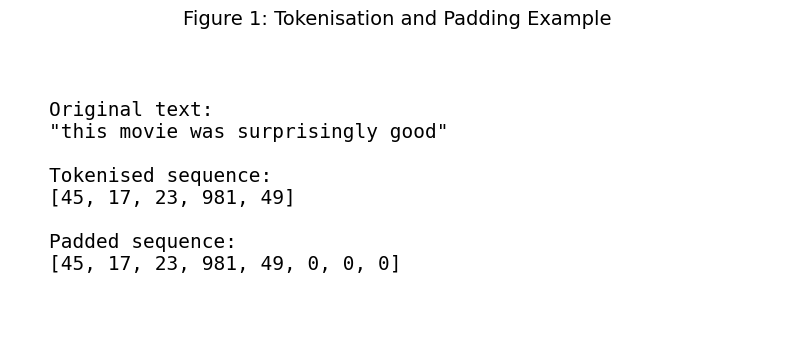

In [7]:
# ============================================================
# CELL 5: FIGURE 1 - TOKENISATION AND PADDING EXAMPLE
# ============================================================
# This figure explains how text becomes numbers before entering
# the neural network.
# ============================================================

example_text = "this movie was surprisingly good"
example_tokens = [45, 17, 23, 981, 49]
example_padded = [45, 17, 23, 981, 49, 0, 0, 0]

plt.figure(figsize=(10, 4))
plt.axis("off")

text = (
    'Original text:\n'
    f'"{example_text}"\n\n'
    'Tokenised sequence:\n'
    f'{example_tokens}\n\n'
    'Padded sequence:\n'
    f'{example_padded}'
)

plt.text(
    0.05, 0.5, text,
    fontsize=14,
    va="center",
    family="monospace"
)

plt.title("Figure 1: Tokenisation and Padding Example", fontsize=14)
plt.savefig("figures/figure_1_tokenisation_padding.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
# ============================================================
# FIXED CELL 6: CUSTOM ATTENTION LAYER
# ============================================================
# This version avoids Keras masking conflict.
# It returns:
# 1. context vector for classification
# 2. attention weights for visualisation
# ============================================================

class AttentionLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.attention_weight = self.add_weight(
            name="attention_weight",
            shape=(input_shape[-1], 1),
            initializer="glorot_uniform",
            trainable=True
        )
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # Calculate attention score for each word position
        score = tf.squeeze(tf.matmul(inputs, self.attention_weight), axis=-1)
        score = tf.nn.tanh(score)

        # Convert scores into attention weights
        attention_weights = tf.nn.softmax(score, axis=1)

        # Weighted sum of BiLSTM outputs
        context_vector = tf.reduce_sum(
            inputs * tf.expand_dims(attention_weights, axis=-1),
            axis=1
        )

        return context_vector, attention_weights

In [12]:
# ============================================================
# FIXED CELL 7: BUILD BILSTM + ATTENTION MODEL
# ============================================================
# Important fix:
# mask_zero=False is used to avoid masking conflict with
# the custom attention layer.
# ============================================================

tf.keras.backend.clear_session()

EMBED_DIM = 32
LSTM_UNITS = 32

inputs = layers.Input(shape=(MAX_LEN,), name="review_input")

embedding = layers.Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM,
    mask_zero=False,   # important fix
    name="embedding"
)(inputs)

bilstm_output = layers.Bidirectional(
    layers.LSTM(LSTM_UNITS, return_sequences=True),
    name="bilstm"
)(embedding)

context_vector, attention_weights = AttentionLayer(name="attention")(bilstm_output)

dense = layers.Dense(32, activation="relu", name="dense_layer")(context_vector)
dropout = layers.Dropout(0.3, name="dropout")(dense)

outputs = layers.Dense(1, activation="sigmoid", name="sentiment_output")(dropout)

model = Model(inputs=inputs, outputs=outputs, name="BiLSTM_Attention_Model")

attention_model = Model(
    inputs=inputs,
    outputs=[outputs, attention_weights],
    name="Attention_Visualisation_Model"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "BiLSTM_Attention_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ review_input (InputLayer)       │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 80, 32)         │       256,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ (None, 80, 64)         │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (AttentionLayer)      │ [(None, 64), (None,    │            64 │
│                                 │ 80)]                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_layer (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sentiment_output (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 274,817 (1.05 MB)

 Trainable params: 274,817 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# ============================================================
# CELL 8: TRAIN MODEL
# ============================================================

EPOCHS = 2
BATCH_SIZE = 64

history = model.fit(
    x_train_pad,
    y_train,
    validation_data=(x_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/2
47/47 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - accuracy: 0.5440 - loss: 0.6911 - val_accuracy: 0.5950 - val_loss: 0.6806
Epoch 2/2
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.7403 - loss: 0.5421 - val_accuracy: 0.7380 - val_loss: 0.5148


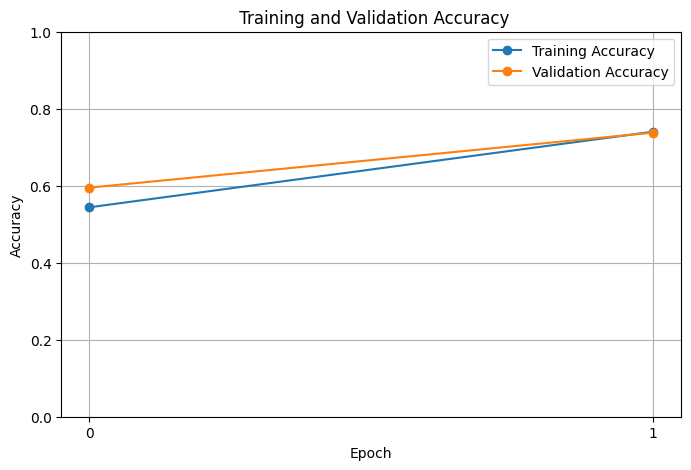

In [15]:
# ============================================================
# CELL 9: FIGURE 2 - TRAINING ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")

plt.title(" Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(range(EPOCHS))
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

plt.savefig("figures/figure_2_training_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

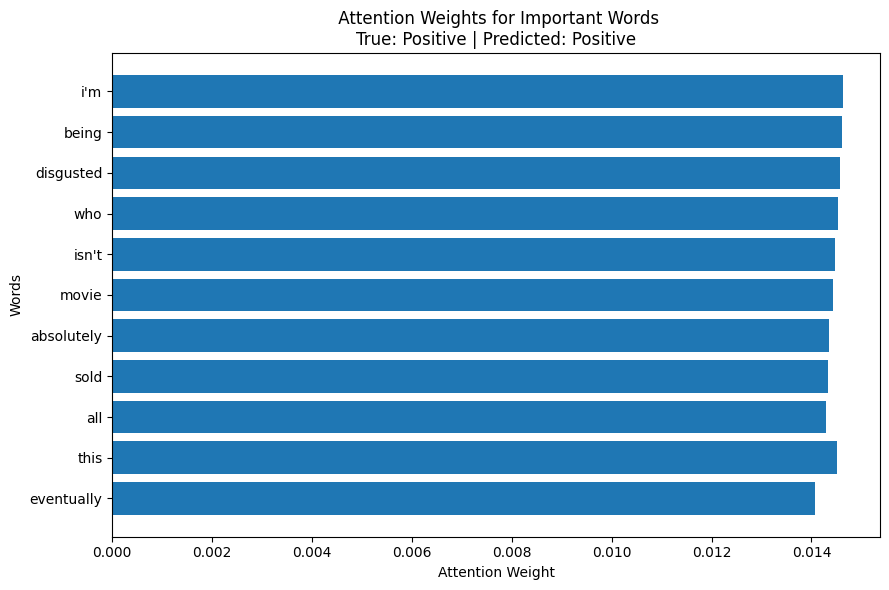

Review snippet:

i'm absolutely disgusted this movie isn't being sold all who love this movie should <UNK> disney and <UNK> the demand for it they'd eventually have to sell it then i'd buy copies for everybody i know everything and everybody in this movie did a good job and i haven't figured out why disney hasn't put this movie on dvd or on vhs in rental stores at least i haven't seen any copies this is a wicked good movie and

True label: Positive
Predicted label: Positive
Prediction probability: 0.8314


In [17]:
# ============================================================
# CELL 10: FIGURE 3 - ATTENTION WEIGHT VISUALISATION
# ============================================================
# This figure shows which words received higher attention.
# ============================================================

def get_words_and_attention(sequence, attention_scores):
    words = []
    scores = []

    for token_id, score in zip(sequence, attention_scores):
        token_id = int(token_id)
        word = reverse_word_index.get(token_id, "<UNK>")

        if word not in ["<PAD>", "<START>", "<UNUSED>"]:
            words.append(word)
            scores.append(float(score))

    return words, scores


# Choose one test review
review_index = 5
single_review = x_test_pad[review_index:review_index + 1]

prediction, attention_scores = attention_model.predict(single_review, verbose=0)

prediction_value = float(prediction[0][0])
predicted_label = "Positive" if prediction_value >= 0.5 else "Negative"
true_label = "Positive" if y_test[review_index] == 1 else "Negative"

words, scores = get_words_and_attention(
    x_test_pad[review_index],
    attention_scores[0]
)

# Select top 12 words by attention score
top_n = 12
top_indices = np.argsort(scores)[-top_n:]
top_words = [words[i] for i in top_indices]
top_scores = [scores[i] for i in top_indices]

# Sort for readable bar chart
sorted_pairs = sorted(zip(top_words, top_scores), key=lambda x: x[1])
top_words_sorted = [pair[0] for pair in sorted_pairs]
top_scores_sorted = [pair[1] for pair in sorted_pairs]

plt.figure(figsize=(9, 6))

plt.barh(top_words_sorted, top_scores_sorted)

plt.title(
    f" Attention Weights for Important Words\n"
    f"True: {true_label} | Predicted: {predicted_label}"
)
plt.xlabel("Attention Weight")
plt.ylabel("Words")

plt.tight_layout()
plt.savefig("figures/figure_3_attention_weights.png", dpi=300, bbox_inches="tight")
plt.show()

print("Review snippet:\n")
print(decode_review(x_test_pad[review_index])[:800])
print("\nTrue label:", true_label)
print("Predicted label:", predicted_label)
print("Prediction probability:", round(prediction_value, 4))

In [18]:
# ============================================================
# CELL 11: PREDICTION EXAMPLES
# ============================================================
# This cell prints short examples with true label, predicted label
# and high-attention words.
# ============================================================

def show_prediction_example(index, top_n=6):
    review = x_test_pad[index:index + 1]
    prediction, attention_scores = attention_model.predict(review, verbose=0)

    prediction_value = float(prediction[0][0])
    predicted_label = "Positive" if prediction_value >= 0.5 else "Negative"
    true_label = "Positive" if y_test[index] == 1 else "Negative"

    words, scores = get_words_and_attention(
        x_test_pad[index],
        attention_scores[0]
    )

    top_indices = np.argsort(scores)[-top_n:]
    important_words = [words[i] for i in top_indices]

    print("=" * 80)
    print("Review snippet:")
    print(decode_review(x_test_pad[index])[:500])
    print("\nTrue sentiment:", true_label)
    print("Predicted sentiment:", predicted_label)
    print("Prediction probability:", round(prediction_value, 4))
    print("High-attention words:", important_words)


for i in [0, 5, 10]:
    show_prediction_example(i)

Review snippet:
please give this one a miss br br <UNK> <UNK> and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite <UNK> so all you madison fans give this a miss

True sentiment: Negative
Predicted sentiment: Negative
Prediction probability: 0.1941
High-attention words: ['miss', 'so', 'a', "wasn't", 'this', 'give']
Review snippet:
i'm absolutely disgusted this movie isn't being sold all who love this movie should <UNK> disney and <UNK> the demand for it they'd eventually have to sell it then i'd buy copies for everybody i know everything and everybody in this movie did a good job and i haven't figured out why disney hasn't put this movie on dvd or on vhs in rental stores at least i haven't seen any copies this is a wicked good movie and

True sentiment: Positive
Predicted sentiment: Positive
Pr

In [19]:
# ============================================================
# CELL 12: FINAL OUTPUT SUMMARY
# ============================================================

test_loss, test_accuracy = model.evaluate(x_test_pad, y_test, verbose=0)

print("Final tutorial model test accuracy:", round(test_accuracy, 4))
print("Final tutorial model test loss:", round(test_loss, 4))

print("\nFigures saved:")
print("figures/figure_1_tokenisation_padding.png")
print("figures/figure_2_training_accuracy.png")
print("figures/figure_3_attention_weights.png")

Final tutorial model test accuracy: 0.7387
Final tutorial model test loss: 0.5169

Figures saved:
figures/figure_1_tokenisation_padding.png
figures/figure_2_training_accuracy.png
figures/figure_3_attention_weights.png
